# Project Description

This project implements a simple NLP system that allows users to ask questions.
The system converts text into embeddings using a Sentence Transformer model.
These embeddings are stored in a vector database (ChromaDB).
When a user asks a question, the system converts it into a vector and searches
for the most semantically similar answers.

In [3]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.1 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-api
    Found

# Prerequisites & Loading Data

In [4]:
import pandas as pd
import os
from sentence_transformers import SentenceTransformer
import chromadb
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_path = "qa_chunks.csv"
if not os.path.exists(data_path):
    raise FileNotFoundError(f"File not found: {data_path}")
data = pd.read_csv(data_path)
texts = data["text"].tolist()
print(f"Step 1 Complete: Loaded {len(texts)} texts successfully.")

model_name = "all-MiniLM-L6-v2"
model = SentenceTransformer(model_name)
print(f"Step 2 Complete: Model '{model_name}' loaded successfully!")

Step 1 Complete: Loaded 1881 texts successfully.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Step 2 Complete: Model 'all-MiniLM-L6-v2' loaded successfully!


# Fast Bulk Encoding & Vector DB Creation

In [5]:
print(" Encoding all texts to dense vectors... Please wait...")
embeddings = model.encode(texts, show_progress_bar=True)
print("Embeddings created successfully!")

client = chromadb.Client()
try:
    client.delete_collection("qa_collection")
except:
    pass

collection = client.create_collection(name="qa_collection")
ids = [str(i) for i in range(len(texts))]
print("\nIndexing vectors into ChromaDB in a single fast batch...")
collection.add(
    documents=texts,
    embeddings=embeddings.tolist(),
    ids=ids
)
print("Vector Database created and populated successfully!")

 Encoding all texts to dense vectors... Please wait...


Batches:   0%|          | 0/59 [00:00<?, ?it/s]

Embeddings created successfully!

Indexing vectors into ChromaDB in a single fast batch...
Vector Database created and populated successfully!


# Interactive Querying & Live Diagnostics Dashboard

Enter your question: Where is my order?

 USER QUERY: 'Where is my order?'

 BEST 3 ANSWERS RETRIEVED:

Rank 1 [Distance: 0.6689]:
   Question: I ordered a toy from your website, and I haven't received it yet. Can you tell me where my order is?
Answer: The order is currently in transit and is expected to arrive within the next two days.
------------------------------------------------------------
Rank 2 [Distance: 0.6953]:
   Question: Can I know the current location of my order?
Answer: Your order is currently in transit and is expected to arrive at our local facility within the next 24 hours.
------------------------------------------------------------
Rank 3 [Distance: 0.8085]:
   Question: Where is the invoice for the order?
Answer: The invoice was sent to the customer's spam folder on the 7th of the month. They have now found it.
------------------------------------------------------------

Generating Live Retrieval Diagnostics...


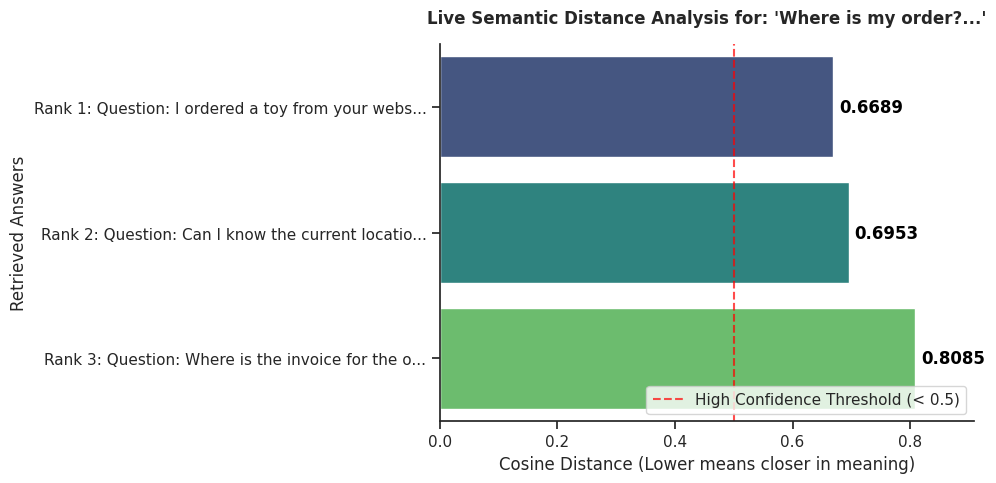

In [6]:
# 1. استقبال السؤال من المستخدم
query = input("Enter your question: ")
if query.strip():
    # 2. تحويل السؤال لـ Vector
    query_vector = model.encode([query])

    # 3. البحث عن أفضل 3 نتائج
    n_results = 3
    results = collection.query(
        query_embeddings=query_vector.tolist(),
        n_results=n_results
    )
    # 4. طباعة النتائج في الـ Console
    print("\n" + "="*60)
    print(f" USER QUERY: '{query}'")
    print("="*60)
    print("\n BEST 3 ANSWERS RETRIEVED:\n")

    for idx in range(n_results):
        print(f"Rank {idx+1} [Distance: {results['distances'][0][idx]:.4f}]:")
        print(f"   {results['documents'][0][idx]}")
        print("-" * 60)

    print("\nGenerating Live Retrieval Diagnostics...")
    sns.set_theme(style="ticks")

    plt.figure(figsize=(10, 5))
    short_answers = [f"Rank {i+1}: {results['documents'][0][i][:40]}..." for i in range(n_results)]
    distances = results['distances'][0]

    ax = sns.barplot(x=distances, y=short_answers, palette="viridis", hue=short_answers, legend=False)
    plt.axvline(0.5, color='red', linestyle='--', alpha=0.7, label='High Confidence Threshold (< 0.5)')

    for i, v in enumerate(distances):
        ax.text(v + 0.01, i, f"{v:.4f}", va='center', fontweight='bold', color='black')
    plt.title(f"Live Semantic Distance Analysis for: '{query[:30]}...'", fontweight='bold', pad=15)
    plt.xlabel("Cosine Distance (Lower means closer in meaning)")
    plt.ylabel("Retrieved Answers")
    plt.xlim(0, max(max(distances) + 0.1, 0.6))
    plt.legend(loc='lower right')
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print(" Please enter a valid question!")